
# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Diabetes prediction dataset.zip to Diabetes prediction dataset.zip


In [3]:
import zipfile
import os

# Remplace par le nom de ton fichier zip
zip_path = "Diabetes prediction dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Extraction terminée")

Extraction terminée


In [5]:

# TODO: load the dataset
# If running on Colab, upload the zip or csv then adjust the path
import pandas as pd

df=pd.read_csv("/content/data/diabetes_prediction_dataset.csv")

print(df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))


(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Missing per column:


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [6]:
# Assume target column is named 'diabetes' with 0 or 1 values
assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
print(df['diabetes'].value_counts())


diabetes
0    91500
1     8500
Name: count, dtype: int64


In [8]:

# TODO: train test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(80000, 8) (20000, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler



> TODO: In a short paragraph, justify Logistic Regression for this binary task. Mention linear decision boundary, calibrated probabilities, and interpretability. Explain why standardization helps for numerical stability and better conditioning.


## Model Picking and Standardization

### 1. Which model can we use and why?

Since this is a **binary classification problem** (diabetes: 0 or 1), we can use supervised learning models such as:

- **Logistic Regression**: A simple and interpretable model that works well for binary classification.
- **Decision Tree / Random Forest**: More powerful models that can capture non-linear relationships in the data.

Logistic Regression is a good starting point because it is fast, easy to interpret, and performs well on structured data.

---

### 2. Do we need to standardize the data?

Yes, standardization is important for some models like Logistic Regression because the features have different scales (e.g., income vs age vs medical values).

If features are not standardized, the model may give more importance to large-scale variables, which can reduce performance.
### 3. standardization or normalisation?
On utilise généralement la standardisation (StandardScaler) dans ce type de projet car les variables ont des échelles différentes, tandis que la normalisation (MinMaxScaler) est moins adaptée pour les modèles classiques comme la régression logistique. on l'utilise plutôt pour les images , les neurons ...

In [12]:
# TODO: build a preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#transform categoriacal columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()


print("Categorical:", cat_cols)
print("Numeric:", num_cols)
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),   # scale numeric columns
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)  # encode categorical
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_test_processed.shape)

Categorical: ['gender', 'smoking_history']
Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
(80000, 15) (20000, 15)


In [15]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['num__age' 'num__hypertension' 'num__heart_disease' 'num__bmi'
 'num__HbA1c_level' 'num__blood_glucose_level' 'cat__gender_Female'
 'cat__gender_Male' 'cat__gender_Other' 'cat__smoking_history_No Info'
 'cat__smoking_history_current' 'cat__smoking_history_ever'
 'cat__smoking_history_former' 'cat__smoking_history_never'
 'cat__smoking_history_not current']


## Exercise 3 - Model training

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)


## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


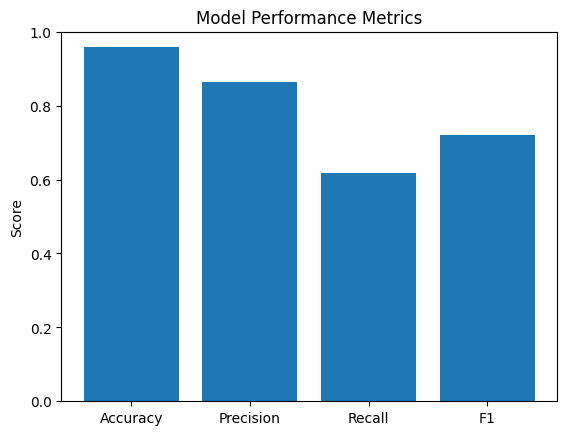

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# predictions
y_pred = model.predict(X_test_processed)

# metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# plot
plt.figure()
plt.bar(['Accuracy', 'Precision', 'Recall', 'F1'], [acc, prec, rec, f1])
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()

> TODO: comment on the balance between precision and recall.
The model prioritizes precision over recall. This means it makes fewer false positive predictions, but it misses a significant number of actual positive cases. In this case, the model is more conservative, which may be useful when false positives are costly, but it is less effective at detecting all positive cases.


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


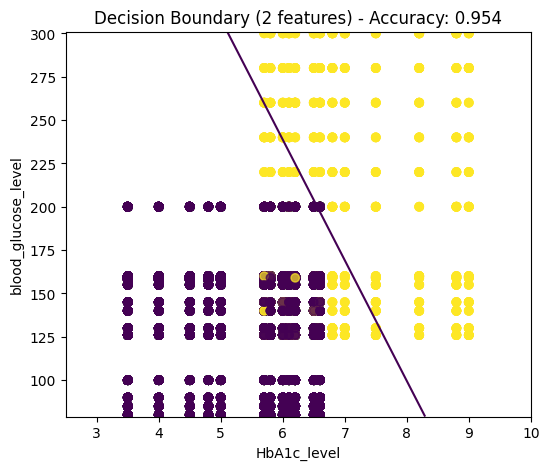

In [21]:
# TODO: If these columns do not exist, change `feat_x` and `feat_y` below to two numeric features that exist in your data.
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Choose 2 numeric features
feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[1]

# Keep only 2 features
X2_train = X_train[[feat_x, feat_y]]
X2_test = X_test[[feat_x, feat_y]]

# Pipeline (scaling + logistic regression)
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# Train model
pipe2.fit(X2_train, y_train)

# Create mesh grid
x_min, x_max = X2_train[feat_x].min() - 1, X2_train[feat_x].max() + 1
y_min, y_max = X2_train[feat_y].min() - 1, X2_train[feat_y].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = pipe2.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6,5))
plt.contour(xx, yy, probs, levels=[0.5])
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, alpha=0.7)

plt.xlabel(feat_x)
plt.ylabel(feat_y)

# Accuracy
acc2 = accuracy_score(y_test, pipe2.predict(X2_test))
plt.title(f'Decision Boundary (2 features) - Accuracy: {acc2:.3f}')

plt.show()

The plot shows that some misclassified points exist, where blue and yellow classes overlap. This indicates that the two selected features are not fully sufficient to perfectly separate the classes. It also shows that the model makes prediction errors in overlapping regions, which is normal in real-world datasets.


## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


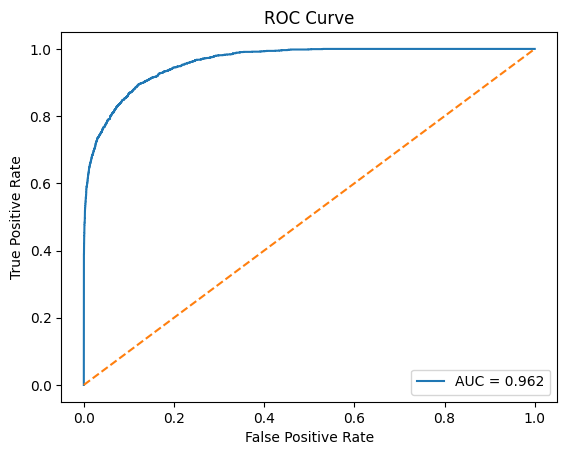

In [22]:
from sklearn import metrics
import matplotlib.pyplot as plt

# probabilities (IMPORTANT: use processed data)
y_proba = model.predict_proba(X_test_processed)[:, 1]

# ROC curve
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)

# AUC
auc = metrics.roc_auc_score(y_test, y_proba)

# plot
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.title('ROC Curve')
plt.show()

> TODO: interpret the ROC curve and AUC from results of execution of cell above.
>The ROC curve shows that the model is able to separate the two classes better than random guessing. The AUC value indicates a good overall performance, meaning the model can distinguish between positive and negative cases with reasonable accuracy.